In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import collections
import torch
import torch.nn as nn
import torch.nn.functional as func
import torch.autograd as autograd
import random
import pandas as pd
import datetime

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device name:',device)

Device name: cuda:0


In [2]:
## Data load ##

# Load the CSV file
csv_file_path = 'ff5_filtered_XY_data_18980_to_19000_0.2s_intervals.csv'
data = pd.read_csv(csv_file_path)

# Set agent list (e.g., from A to N)
agents = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N']
valid_agents = [agent for agent in agents if f'X(m)_{agent}' in data.columns and f'Y(m)_{agent}' in data.columns]

# Convert t(s) data to tensor
t_tensor = torch.tensor(data['t(s)'].values, dtype=torch.float32).to(device)

# Lists to store X, Y, dX/dt, dY/dt data (prepared to make 2D tensors for each)
X_data, Y_data, dX_data, dY_data = [], [], [], []

# Add X, Y, dX/dt, dY/dt data to the list for each agent
for agent in agents:
    if f'X(m)_{agent}' in data.columns and f'Y(m)_{agent}' in data.columns:
        X_data.append(data[f'X(m)_{agent}'].values)
        Y_data.append(data[f'Y(m)_{agent}'].values)
    if f'dX/dt(m/s)_{agent}' in data.columns and f'dY/dt(m/s)_{agent}' in data.columns:
        dX_data.append(data[f'dX/dt(m/s)_{agent}'].values)
        dY_data.append(data[f'dY/dt(m/s)_{agent}'].values)

# Convert the list to tensor (convert each to a 2D tensor, rows represent time, columns represent agents)
X_tensor = torch.tensor(X_data, dtype=torch.float32).T.to(device)  # transpose to match shape [time, agents]
Y_tensor = torch.tensor(Y_data, dtype=torch.float32).T.to(device)
dX_tensor = torch.tensor(dX_data, dtype=torch.float32).T.to(device)
dY_tensor = torch.tensor(dY_data, dtype=torch.float32).T.to(device)

t_tensor = (t_tensor - t_tensor[0]).reshape(len(t_tensor), 1)
X_tensor = X_tensor - torch.mean(X_tensor)
Y_tensor = Y_tensor - torch.mean(Y_tensor)

# Group tensors into a dictionary
tensor_dict = {
    't': t_tensor,
    'X': X_tensor,
    'Y': Y_tensor,
    'dX/dt': dX_tensor,
    'dY/dt': dY_tensor
}

v0_mean = torch.mean(torch.sqrt(dX_tensor**2 + dY_tensor**2))

C:\Users\USER\anaconda3\envs\pytorch\lib\site-packages\ipykernel_launcher.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ..\torch\csrc\utils\tensor_new.cpp:201.)


In [3]:
eps = torch.finfo(torch.float32).eps

class PINN(nn.Module):
    def __init__(self, input_num, output_num, receivers, senders, radius, bias=True):
        super().__init__()
        
        self.bias=bias
        self.radius_tg = radius
        self.fc1 = nn.Linear(input_num,32, bias=bias)
        self.fc2 = nn.Linear(32,32, bias=bias)
        self.fc3 = nn.Linear(32,32, bias=bias)
        self.fc4 = nn.Linear(32, output_num, bias=bias)
        self.reset_parameters()
        
        self.receivers=receivers
        self.senders=senders
        
        self.lambda1 = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.lambda2 = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.lambda3 = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.lambda4 = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.power1 = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.power2 = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.power3 = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        
        self.lambda1_v = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.lambda2_v = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.lambda3_v = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.lambda4_v = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.power1_v = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.power2_v = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        self.power3_v = nn.Parameter(torch.FloatTensor(1).uniform_(-0.1, 0.1).requires_grad_(True).to(device))
        
        self.a1_dist = nn.Parameter(torch.tensor([0.1]).requires_grad_(True).to(device))
        self.a2_dist = nn.Parameter(torch.tensor([-5.]).requires_grad_(True).to(device))
        self.a3_dist = nn.Parameter(torch.tensor([0.1]).requires_grad_(True).to(device))
        self.a4_dist = nn.Parameter(torch.tensor([1.0]).requires_grad_(True).to(device))
        self.a5_dist = nn.Parameter(torch.tensor([0.1]).requires_grad_(True).to(device))

        self.a1_v = nn.Parameter(torch.tensor([0.1]).requires_grad_(True).to(device))
        self.a2_v = nn.Parameter(torch.tensor([-5.]).requires_grad_(True).to(device))
        self.a3_v = nn.Parameter(torch.tensor([0.1]).requires_grad_(True).to(device))
        self.a4_v = nn.Parameter(torch.tensor([1.0]).requires_grad_(True).to(device))
        self.a5_v = nn.Parameter(torch.tensor([0.1]).requires_grad_(True).to(device))

        self.tau = nn.Parameter(torch.tensor([1.0]).requires_grad_(True).to(device))
        
    def forward(self, x):
        self.input = x
        self.row_num = x.size(0)
        x_max = x[-1].item()//2
        
        x=(self.input-x_max)/x_max
        self.x1=torch.tanh(self.fc1(x))
        self.x2=torch.tanh(self.fc2(self.x1))
        self.x3=torch.tanh(self.fc3(self.x2))
        self.x4 = self.fc4(self.x3)
        output =radius*self.x4
        
        return output

    def reset_parameters(self) -> None:
        nn.init.xavier_uniform_(self.fc1.weight, gain = nn.init.calculate_gain('tanh'))
        nn.init.xavier_uniform_(self.fc2.weight, gain = nn.init.calculate_gain('tanh'))
        nn.init.xavier_uniform_(self.fc3.weight, gain = nn.init.calculate_gain('tanh'))
        nn.init.xavier_uniform_(self.fc4.weight, gain=1)
        
        if self.bias:
            nn.init.constant_(self.fc1.bias, 0.1)
            nn.init.constant_(self.fc2.bias, 0.1)
            nn.init.constant_(self.fc3.bias, 0.1)
            nn.init.constant_(self.fc4.bias, 0.1)
            
    def loss_func(self, pred, data, v0, radius=2):
        #calculate gradients
        
        num_agents = data['X'].shape[1]
        loss_mse = nn.MSELoss().to(device)
        
        for i in range(pred.size(1)):
            temp=torch.zeros_like(pred)
            temp[:,i]=1
            grads, = autograd.grad(pred, self.input, grad_outputs=temp, create_graph=True)
            if i==0:
                self.u = grads
            else:
                self.u = torch.hstack((self.u, grads))

        self.u_mag=torch.sqrt(torch.square(self.u[:,0:num_agents])+torch.square(self.u[:,num_agents:]))

        for i in range(pred.size(1)):
            temp=torch.zeros_like(pred)
            temp[:,i]=1
            grads, = autograd.grad(self.u, self.input, grad_outputs=temp, create_graph=True)
            if i==0:
                self.accel = grads
            else:
                self.accel = torch.hstack((self.accel, grads))
        
        N_time=pred.size(0)
        
        
        ##### calculate distance #########

        pos_x = pred[:,0:num_agents]
        pos_y = pred[:,num_agents:]
        pos_x_r = pos_x[:, self.receivers.flatten().type(torch.int64)]
        pos_y_r = pos_y[:, self.receivers.flatten().type(torch.int64)]
        pos_x_s = pos_x[:, self.senders.flatten().type(torch.int64)]
        pos_y_s = pos_y[:, self.senders.flatten().type(torch.int64)]

        dist_x = pos_x_r - pos_x_s
        dist_y = pos_y_r - pos_y_s
        dist = torch.sqrt(torch.square(dist_x)+torch.square(dist_y))
        self.dist_value = dist.detach()
        self.dist_max = torch.max(self.dist_value)

        
        ##### calculate relative velocity distance #########
        
        vel_x = self.u[:,0:num_agents]
        vel_y = self.u[:,num_agents:]
        vel_x_r = vel_x[:, self.receivers.flatten().type(torch.int64)]
        vel_y_r = vel_y[:, self.receivers.flatten().type(torch.int64)]
        vel_x_s = vel_x[:, self.senders.flatten().type(torch.int64)]
        vel_y_s = vel_y[:, self.senders.flatten().type(torch.int64)]
        
        vel_rel_x = vel_x_r - vel_x_s
        vel_rel_y = vel_y_r - vel_y_s
        vel_rel = torch.sqrt(torch.square(vel_rel_x)+torch.square(vel_rel_y))
        
        u_x_r = self.u[:,self.receivers.flatten().type(torch.int64)]
        u_y_r = self.u[:,num_agents + self.receivers.flatten().type(torch.int64)]
        u_mag_r = torch.sqrt(torch.square(u_x_r)+torch.square(u_y_r))
        
        ### Define h(theta) ###
        self.ang_interact = torch.atan2(u_y_r * (-dist_x) - u_x_r * (-dist_y), u_x_r * (-dist_x) + u_y_r * (-dist_y))
        self.ang_eff_dist = torch.sigmoid((self.a1_dist*torch.cos(1*self.ang_interact)+
                                           self.a2_dist*torch.cos(2*self.ang_interact)+
                                           self.a3_dist*torch.cos(3*self.ang_interact)+
                                           self.a4_dist*torch.cos(4*self.ang_interact)+
                                           self.a5_dist))
        self.ang_eff_vel = torch.sigmoid((self.a1_v*torch.cos(1*self.ang_interact)+
                                          self.a2_v*torch.cos(2*self.ang_interact)+
                                          self.a3_v*torch.cos(3*self.ang_interact)+
                                          self.a4_v*torch.cos(4*self.ang_interact)+
                                          self.a5_v))
        
        ######## calculate loss between output edges and f_inter matgnitude from physics ######
        self.f_inter_x= (dist_x/dist)*(self.lambda1*(dist**self.power1)+self.lambda2*(dist**self.power2)+\
                                      self.lambda3*(dist**self.power3)+self.lambda4)*self.ang_eff_dist +\
        (vel_rel_x/vel_rel)*(self.lambda1_v*(dist**self.power1_v) + self.lambda2_v*(dist**self.power2_v)+\
                             self.lambda3_v*(dist**self.power3_v) + self.lambda4_v)*self.ang_eff_vel
        
        self.f_inter_y=(dist_y/dist)*(self.lambda1*(dist**self.power1)+self.lambda2*(dist**self.power2)+\
                                      self.lambda3*(dist**self.power3)+self.lambda4)*self.ang_eff_dist +\
        (vel_rel_y/vel_rel)*(self.lambda1_v*(dist**self.power1_v) + self.lambda2_v*(dist**self.power2_v)+\
                             self.lambda3_v*(dist**self.power3_v) + self.lambda4_v)*self.ang_eff_vel
        

        f_agg_x = torch.zeros(self.row_num, num_agents).to(device)
        f_agg_y = torch.zeros(self.row_num, num_agents).to(device)

        f_agg_x = f_agg_x.scatter_add_(1, self.receivers.flatten().repeat(self.row_num,1).type(torch.int64), self.f_inter_x).to(device)
        f_agg_y = f_agg_y.scatter_add_(1, self.receivers.flatten().repeat(self.row_num,1).type(torch.int64), self.f_inter_y).to(device)
        
        ######## Self propelled term #########        
        
        sp_x = (1/torch.sqrt(torch.square(self.tau)))*self.u[:,0:num_agents]*(v0/self.u_mag - 1)
        sp_y = (1/torch.sqrt(torch.square(self.tau)))*self.u[:,num_agents:]*(v0/self.u_mag - 1)
        
        ode_x = self.accel[:,0:num_agents]-sp_x-f_agg_x
        ode_y = self.accel[:,num_agents:]-sp_y-f_agg_y

        self.loss_force = torch.sum(torch.square(ode_x[:,1:])+torch.square(ode_y[:,1:]))/(pred.size(0)*(num_agents-1)) #without agent A (i=0)
        
        
        ########### Loss from data##########
        self.loss_pos_x = loss_mse(pred[:, 0:num_agents], data['X'])
        self.loss_pos_y = loss_mse(pred[:, num_agents:], data['Y'])
        
        loss = 1*self.loss_pos_x + 1*self.loss_pos_y + 1*self.loss_force
   
        return loss


In [4]:
########## Inital condition ##########

position_list_x=[]
position_list_y=[]
velocity_list_x=[]
velocity_list_y=[]
random.seed(101)
num_agents = tensor_dict['X'].shape[1]


senders=[]
receivers=[]

for i in range(num_agents):
    for j in range(num_agents-1):
        receivers.append([i])
    for k in range(num_agents):
        if k!=i:
            senders.append([k])


senders_G= torch.tensor(senders, dtype=torch.float32).to(device)  #index of the sender node for edge
receivers_G= torch.tensor(receivers, dtype=torch.float32).to(device)  #index of the receiver node for edge


In [5]:
def closure():
    model.train()
    optimizer_LBFGS.zero_grad()
    pred=model(t)
    loss=model.loss_func(pred, data=tensor_dict, v0 = v0_mean, radius=radius)

    if torch.isfinite(loss).item:
        loss.backward() 
    else:
        pass

    return loss

In [6]:

#### define hyperparameter####


epoch_adam=200
epoch_LBFGS=1000
patience=-21
tolerance=1e-4

#### define input ####
t = tensor_dict['t'].requires_grad_(True)
radius = torch.mean(torch.sqrt(tensor_dict['X']**2 + tensor_dict['Y']**2))
num_agents = tensor_dict['X'].shape[1]
out_num = num_agents*2

retry_num = 100

print("Training Started")
for ii in range(retry_num):
    loss_value=[]
    ##define model
    model=PINN(input_num=1, output_num=out_num, receivers=receivers_G, senders=senders_G, radius = radius).to(device)


    ## ADAM ##
    for i in range(epoch_adam):
        learning_rate = 0.001
        optimizer_adam=torch.optim.Adam(model.parameters(), lr=learning_rate)

        model.train()
        optimizer_adam.zero_grad()

        pred=model(t)
        loss=model.loss_func(pred, data=tensor_dict, v0 = v0_mean, radius=radius)

        loss.backward()
        optimizer_adam.step()
        loss_value.append(loss.item())

        ### Early Stop condition ###
        if i>21:
            if loss_value[-1] <= loss_value[-2] and abs(loss_value[-1]-np.mean(loss_value[patience:-1])) < tolerance:
                break


    ##LBFGS ##
    optimizer_LBFGS=torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, line_search_fn = 'strong_wolfe')

    for i in range(epoch_LBFGS):

        loss_prev = optimizer_LBFGS.step(closure)
        if torch.isfinite(loss_prev) == False:
            break

        loss_value.append(loss_prev.item())
        ### Early Stop condition ###
        if i>21:
            if loss_value[-1] <= loss_value[-2] and abs(loss_value[-1]-np.mean(loss_value[patience:-1])) < tolerance:
                break

    ### Stopping Condition ####
    if model.loss_force.item()<5 and (model.loss_pos_x + model.loss_pos_y )/2 < 1:
        break
            
print("Training Stopped")
print('#Distance coeff')
print("lambda1 = %.3e \nlambda2 = %.3e \nlambda3 = %.3e \nlambda4 = %.3e" \
      %(model.lambda1, model.lambda2, model.lambda3, model.lambda4))
print("power1 = %.3e \npower2 = %.3e \npower3 = %.3e" \
      %(model.power1, model.power2, model.power3))
print('#Velocity coeff')
print("lambda1_v = %.3e \nlambda2_v = %.3e \nlambda3_v = %.3e \nlambda4_v = %.3e" \
      %(model.lambda1_v, model.lambda2_v, model.lambda3_v, model.lambda4_v))
print("power1_v = %.3e \npower2_v = %.3e \npower3_v = %.3e" \
      %(model.power1_v, model.power2_v, model.power3_v))
print('#Angle coeff (distance-based)')
print("a1_dist = %.4e \na2_dist = %.4e \na3_dist = %.4e \na4_dist = %.4e \na5_dist = %.4e" \
      % (model.a1_dist.item(), model.a2_dist.item(), model.a3_dist.item(), model.a4_dist.item(), model.a5_dist.item()))
print('#Angle coeff (velocity-based)')
print("a1_v = %.4e \na2_v = %.4e \na3_v = %.4e \na4_v = %.4e \na5_v = %.4e" % (
    model.a1_v.item(), model.a2_v.item(), model.a3_v.item(), model.a4_v.item(), model.a5_v.item()))

print("#Relaxation time, Tau")
print("tau = %.4e" % model.tau.item())

Training Started
Training Stopped
#Distance coeff
lambda1 = -9.578e-03 
lambda2 = 8.146e-01 
lambda3 = -2.046e-01 
lambda4 = 4.526e-01
power1 = 1.049e+00 
power2 = 6.725e-02 
power3 = 6.548e-01
#Velocity coeff
lambda1_v = 5.457e-02 
lambda2_v = -1.544e-04 
lambda3_v = -1.876e-02 
lambda4_v = -7.655e-02
power1_v = 3.957e-01 
power2_v = 2.263e+00 
power3_v = 7.637e-01
#Angle coeff (distance-based)
a1_dist = 1.5811e+00 
a2_dist = -4.6700e+00 
a3_dist = -1.1846e+00 
a4_dist = 8.3358e-01 
a5_dist = 5.9184e-01
#Angle coeff (velocity-based)
a1_v = 3.9551e+00 
a2_v = -4.8645e+00 
a3_v = -1.9171e+00 
a4_v = 5.6337e-01 
a5_v = 7.9407e-02
#Relaxation time, Tau
tau = 8.2404e+00


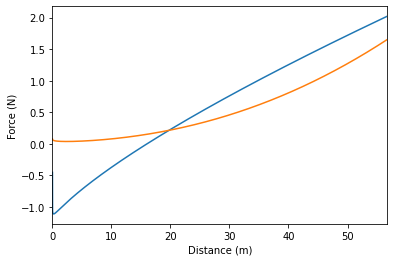

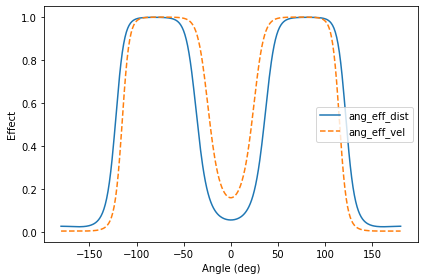

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

l1, l2, l3, l4 = model.lambda1.item(), model.lambda2.item(), model.lambda3.item(), model.lambda4.item()
p1, p2, p3 = model.power1.item(), model.power2.item(), model.power3.item()

l1_v, l2_v, l3_v, l4_v = model.lambda1_v.item(), model.lambda2_v.item(), model.lambda3_v.item(), model.lambda4_v.item()
p1_v, p2_v, p3_v = model.power1_v.item(), model.power2_v.item(), model.power3_v.item()

xij=np.arange(0,model.dist_max.item(),0.01)

F_d = -(l1*np.power(xij,p1) + l2*np.power(xij,p2) + l3*np.power(xij,p3) + l4)
F_v = -(l1_v*np.power(xij,p1_v) + l2_v*np.power(xij,p2_v) + l3_v*np.power(xij,p3_v) + l4_v)

plt.plot(xij,F_d)
plt.plot(xij,F_v)
plt.xlim(0, model.dist_max.item())
plt.xlabel('Distance (m)')
plt.ylabel('Force (N)')
plt.show()



a1, a2, a3, a4, a5 = model.a1_dist.item(), model.a2_dist.item(), model.a3_dist.item(), model.a4_dist.item(), model.a5_dist.item()

a1v, a2v, a3v, a4v, a5v = model.a1_v.item(), model.a2_v.item(), model.a3_v.item(), model.a4_v.item(), model.a5_dist.item()



x = np.radians(np.linspace(-180, 180, 500))

y1 = sigmoid((a1*np.cos(1*x) + a2*np.cos(2*x) + a3*np.cos(3*x) + a4*np.cos(4*x)+ a5))
y2 = sigmoid((a1v*np.cos(1*x) + a2v*np.cos(2*x) + a3v*np.cos(3*x) + a4v*np.cos(4*x)+ a5v))

plt.plot(np.degrees(x), y1, label='ang_eff_dist')
plt.plot(np.degrees(x), y2, label='ang_eff_vel', linestyle='--')
plt.xlabel('Angle (deg)'); plt.ylabel('Effect'); plt.legend(); plt.tight_layout(); plt.show()